<a href="https://colab.research.google.com/github/arifbin120/Pizza-price-prediction-using-SLRM-MLRM/blob/main/pizza_regression_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🍕 Pizza Price Prediction — End-to-End ML Pipeline
### Simple Linear Regression & Multiple Linear Regression

**Pipeline Steps:**
1. Data Loading & Overview
2. Exploratory Data Analysis (EDA) + Visualizations
3. Data Preprocessing (Cleaning, Imputation)
4. Label Encoding / One-Hot Encoding
5. Feature Engineering
6. StandardScaler
7. Train-Test Split
8. Simple Linear Regression
9. Multiple Linear Regression
10. Model Evaluation & Comparison

## 📦 Step 0 — Install & Import Libraries

In [2]:
# Core libraries
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Models
from sklearn.linear_model import LinearRegression

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print('All libraries loaded successfully!')

All libraries loaded successfully!


## 📂 Step 1 — Load Dataset

In [3]:
# -------------------------------------------------------
# If running in Google Colab, upload your file first:
# from google.colab import files
# uploaded = files.upload()   # choose pizza_v1.csv
# -------------------------------------------------------

df = pd.read_csv('/content/pizza_v1.csv')   # change path if needed

print('Dataset Shape:', df.shape)
print('\nColumn Names:', df.columns.tolist())
df.head(10)

Dataset Shape: (129, 8)

Column Names: ['company', 'price_rupiah', 'diameter', 'topping', 'variant', 'size', 'extra_sauce', 'extra_cheese']


,company,price_rupiah,diameter,topping,variant,size,extra_sauce,extra_cheese
0,A,"Rp235,000",22.0,chicken,double_signature,jumbo,yes,yes
1,A,"Rp198,000",20.0,papperoni,double_signature,jumbo,yes,yes
2,A,"Rp120,000",16.0,mushrooms,double_signature,reguler,yes,yes
3,A,"Rp155,000",14.0,smoked beef,double_signature,reguler,yes,no
4,A,"Rp248,000",18.0,mozzarella,double_signature,jumbo,yes,no
5,A,"Rp140,000",18.5,black papper,american_favorite,jumbo,no,no
6,A,"Rp110,000",16.0,smoked beef,american_favorite,jumbo,no,yes
7,A,"Rp70,000",8.0,papperoni,american_favorite,reguler,no,no
8,A,"Rp90,000",12.0,mushrooms,american_favorite,reguler,yes,no
9,A,"Rp90,000",12.0,smoked beef,american_favorite,reguler,no,no


In [4]:
print('=== DATASET INFO ===')
df.info()
print('\n=== STATISTICAL SUMMARY ===')
df.describe(include='all')

=== DATASET INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129 entries, 0 to 128
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   company       129 non-null    object 
 1   price_rupiah  129 non-null    object 
 2   diameter      129 non-null    float64
 3   topping       129 non-null    object 
 4   variant       129 non-null    object 
 5   size          129 non-null    object 
 6   extra_sauce   129 non-null    object 
 7   extra_cheese  129 non-null    object 
dtypes: float64(1), object(7)
memory usage: 8.2+ KB

=== STATISTICAL SUMMARY ===


,company,price_rupiah,diameter,topping,variant,size,extra_sauce,extra_cheese
count,129,129,129.000000,129,129,129,129,129
unique,5,43,NaN,12,20,6,2,2
top,C,"Rp72,000",NaN,chicken,classic,medium,yes,yes
freq,30,11,NaN,29,30,41,76,86
mean,NaN,NaN,12.976744,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,3.272674,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,8.000000,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,12.000000,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,12.000000,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,14.000000,NaN,NaN,NaN,NaN,NaN


In [5]:
print('=== NULL VALUE COUNT ===')
print(df.isnull().sum())
print('\n=== DUPLICATE ROWS ===')
print(f'Total duplicates: {df.duplicated().sum()}')

=== NULL VALUE COUNT ===
company         0
price_rupiah    0
diameter        0
topping         0
variant         0
size            0
extra_sauce     0
extra_cheese    0
dtype: int64

=== DUPLICATE ROWS ===
Total duplicates: 3


## 📊 Step 2 — Exploratory Data Analysis (EDA) & Visualizations

In [6]:
# -----------------------------------------------------------
# price_rupiah is stored as a string like 'Rp235,000'
# We must clean it BEFORE plotting — preview the raw values
# -----------------------------------------------------------
print('Sample raw price values:')
print(df['price_rupiah'].value_counts().head(10))

Sample raw price values:
price_rupiah
Rp72,000     11
Rp90,000      8
Rp46,000      7
Rp83,000      5
Rp49,000      5
Rp75,000      5
Rp96,000      5
Rp140,000     4
Rp149,000     4
Rp110,000     4
Name: count, dtype: int64


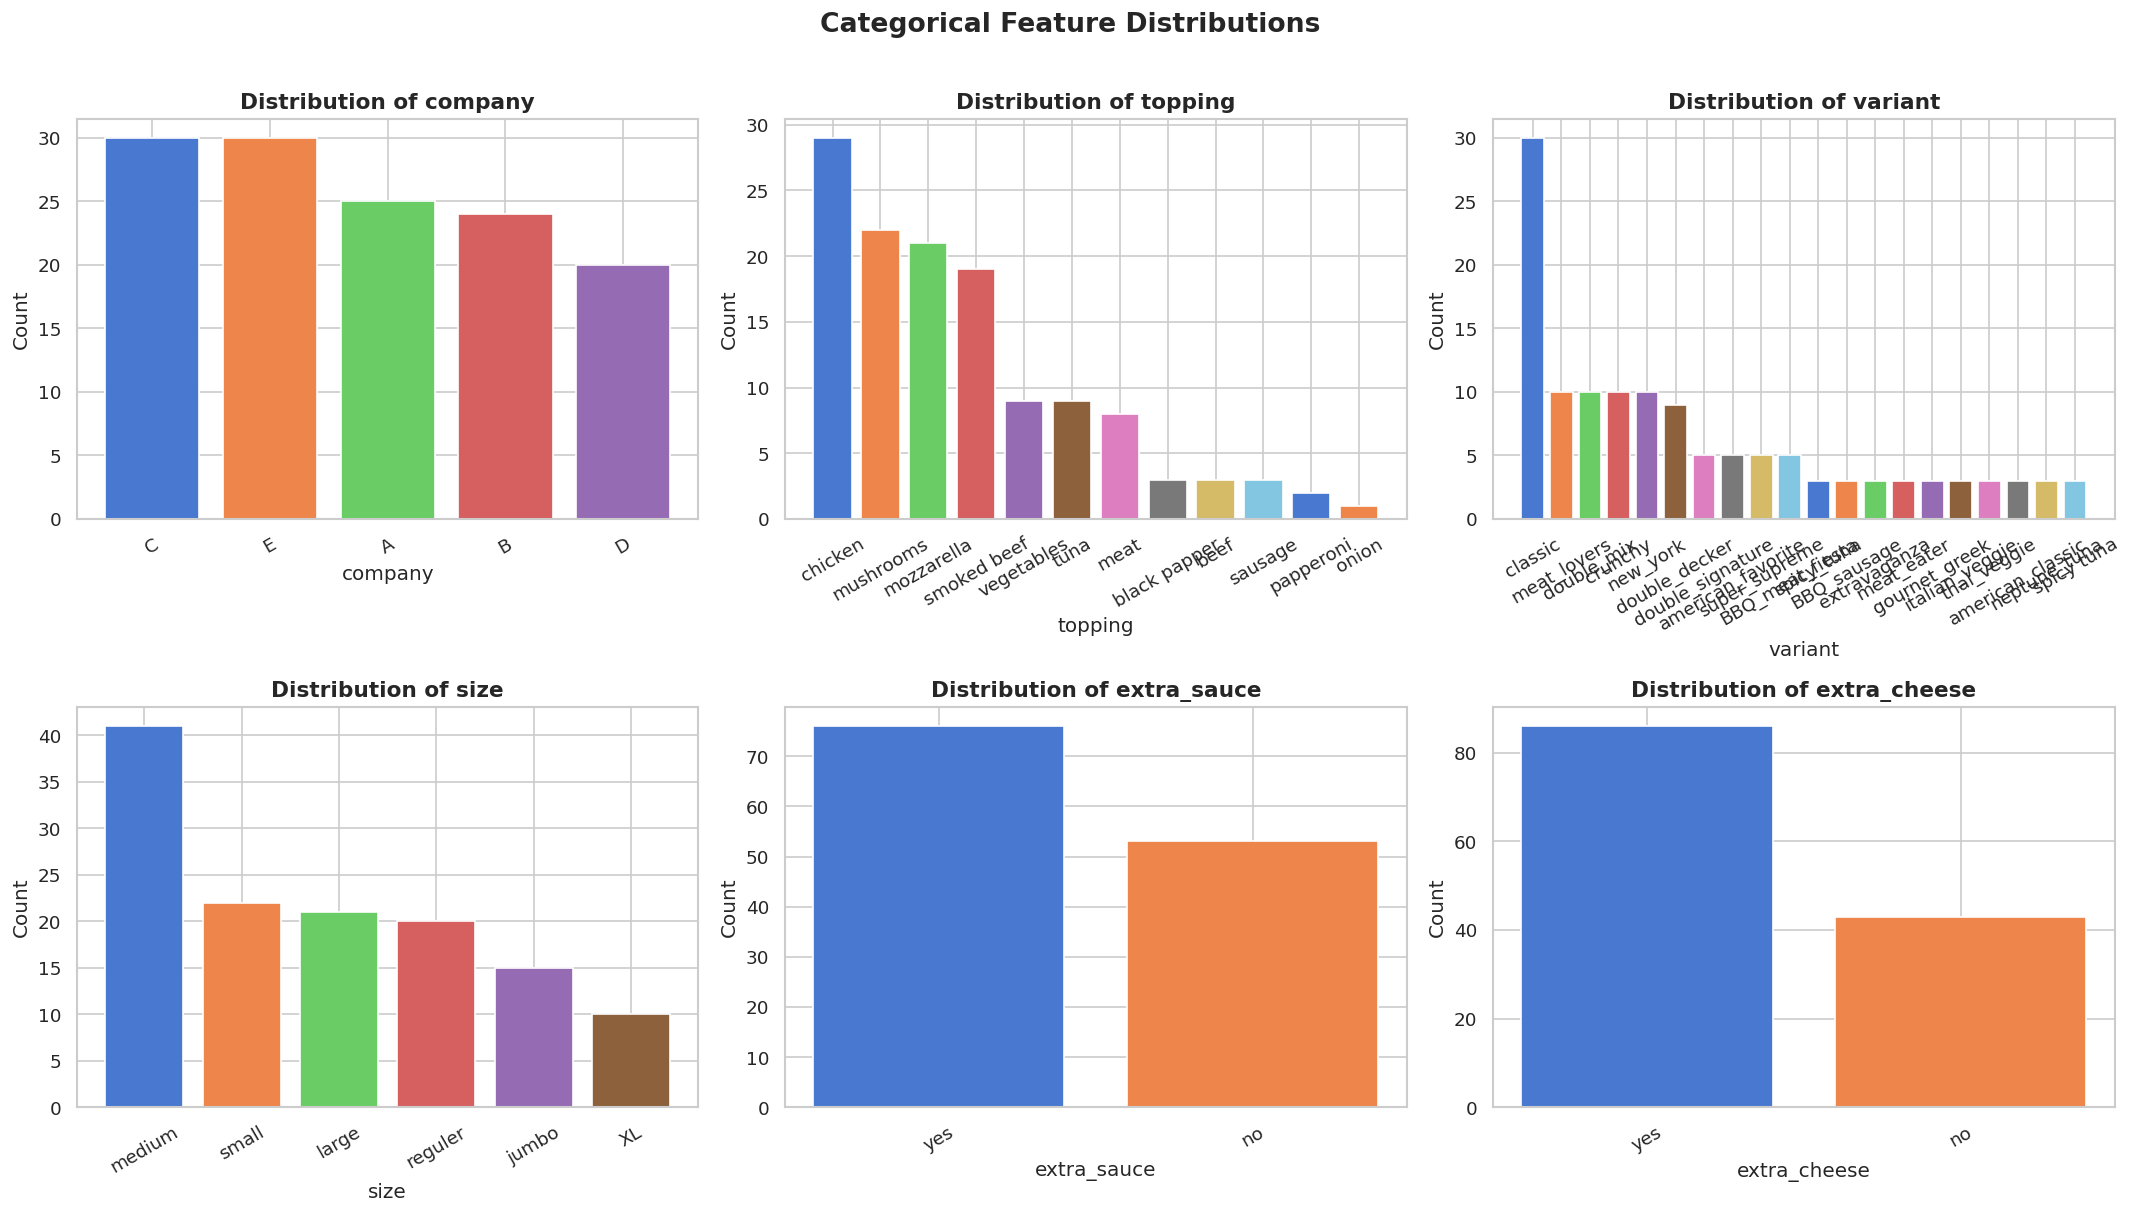

In [7]:
# ---- Categorical column value counts ----


# COMAPNIES = A,B,C,D,E
cat_cols = ['company', 'topping', 'variant', 'size', 'extra_sauce', 'extra_cheese']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    axes[i].bar(counts.index, counts.values,
                color=sns.color_palette('muted', len(counts)))
    axes[i].set_title(f'Distribution of {col}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Categorical Feature Distributions', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

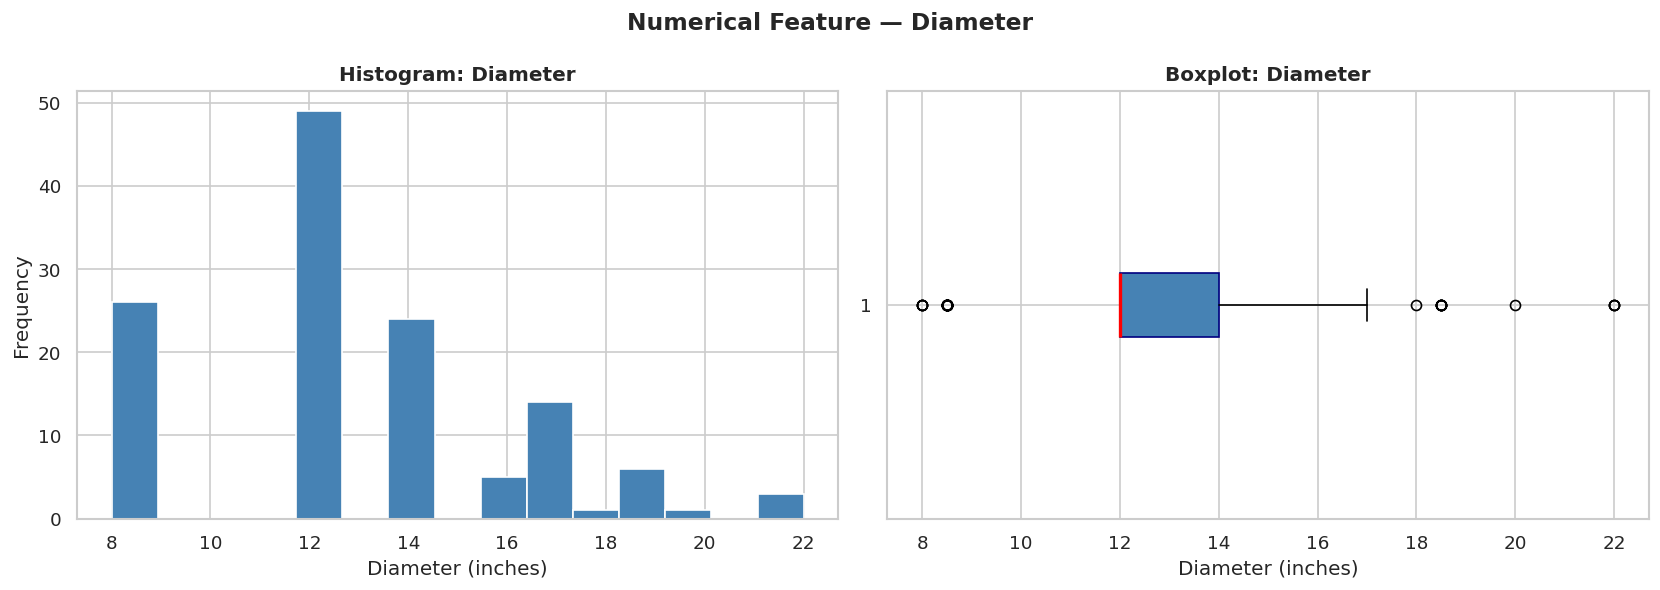

In [8]:
# ---- Diameter distribution ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['diameter'], bins=15, color='steelblue', edgecolor='white')
axes[0].set_title('Histogram: Diameter', fontweight='bold')
axes[0].set_xlabel('Diameter (inches)')
axes[0].set_ylabel('Frequency')

axes[1].boxplot(df['diameter'], vert=False, patch_artist=True,
                boxprops=dict(facecolor='steelblue', color='navy'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Boxplot: Diameter', fontweight='bold')
axes[1].set_xlabel('Diameter (inches)')

plt.suptitle('Numerical Feature — Diameter', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 🔧 Step 3 — Data Preprocessing & Cleaning

In [9]:
# ---- Clean price_rupiah: 'Rp235,000' → 235000.0 ----
df['price_rupiah'] = (
    df['price_rupiah']
    .str.replace('Rp', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(float)
)

print('price_rupiah after cleaning:')
print(df['price_rupiah'].describe())
print('\nSample values:', df['price_rupiah'].head().tolist())

price_rupiah after cleaning:
count       129.000000
mean      87151.162791
std       44706.097732
min       23500.000000
25%       51000.000000
50%       78000.000000
75%      105000.000000
max      248000.000000
Name: price_rupiah, dtype: float64

Sample values: [235000.0, 198000.0, 120000.0, 155000.0, 248000.0]


In [11]:
# ---- Imputation ----
# (No nulls in this dataset, but we apply best-practice imputation anyway
#  so the pipeline is production-ready if new data has missing values)

# Numerical columns → fill with median (robust to outliers)
num_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
for col in num_cols:
    median_val = df[col].median()
    df[col].fillna(median_val, inplace=True)
    print(f'  {col}: filled NaN with median = {median_val}')

# Categorical columns → fill with mode
cat_cols_all = df.select_dtypes(include=['object', 'string']).columns.tolist()
for col in cat_cols_all:
    mode_val = df[col].mode()[0]
    df[col].fillna(mode_val, inplace=True)
    print(f'  {col}: filled NaN with mode = {mode_val}')

print('\n Null values after imputation:', df.isnull().sum().sum())

  price_rupiah: filled NaN with median = 78000.0
  diameter: filled NaN with median = 12.0
  company: filled NaN with mode = C
  topping: filled NaN with mode = chicken
  variant: filled NaN with mode = classic
  size: filled NaN with mode = medium
  extra_sauce: filled NaN with mode = yes
  extra_cheese: filled NaN with mode = yes

 Null values after imputation: 0


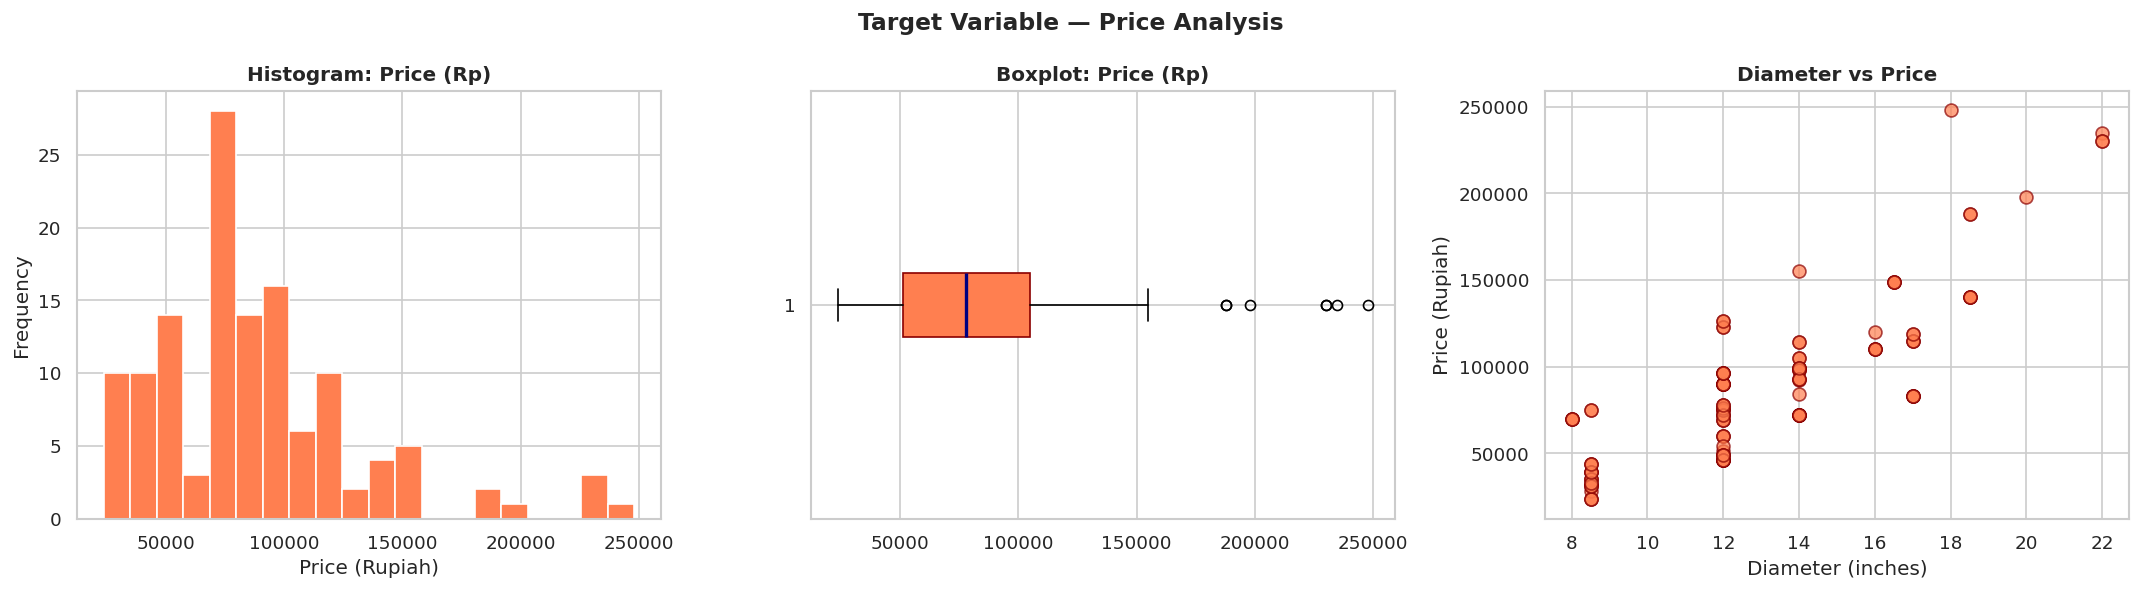

In [12]:
# ---- Price distribution (after cleaning) ----
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df['price_rupiah'], bins=20, color='coral', edgecolor='white')
axes[0].set_title('Histogram: Price (Rp)', fontweight='bold')
axes[0].set_xlabel('Price (Rupiah)')
axes[0].set_ylabel('Frequency')

axes[1].boxplot(df['price_rupiah'], vert=False, patch_artist=True,
                boxprops=dict(facecolor='coral', color='darkred'),
                medianprops=dict(color='navy', linewidth=2))
axes[1].set_title('Boxplot: Price (Rp)', fontweight='bold')

axes[2].scatter(df['diameter'], df['price_rupiah'],
                alpha=0.7, c='coral', edgecolors='darkred', s=60)
axes[2].set_title('Diameter vs Price', fontweight='bold')
axes[2].set_xlabel('Diameter (inches)')
axes[2].set_ylabel('Price (Rupiah)')

plt.suptitle('Target Variable — Price Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

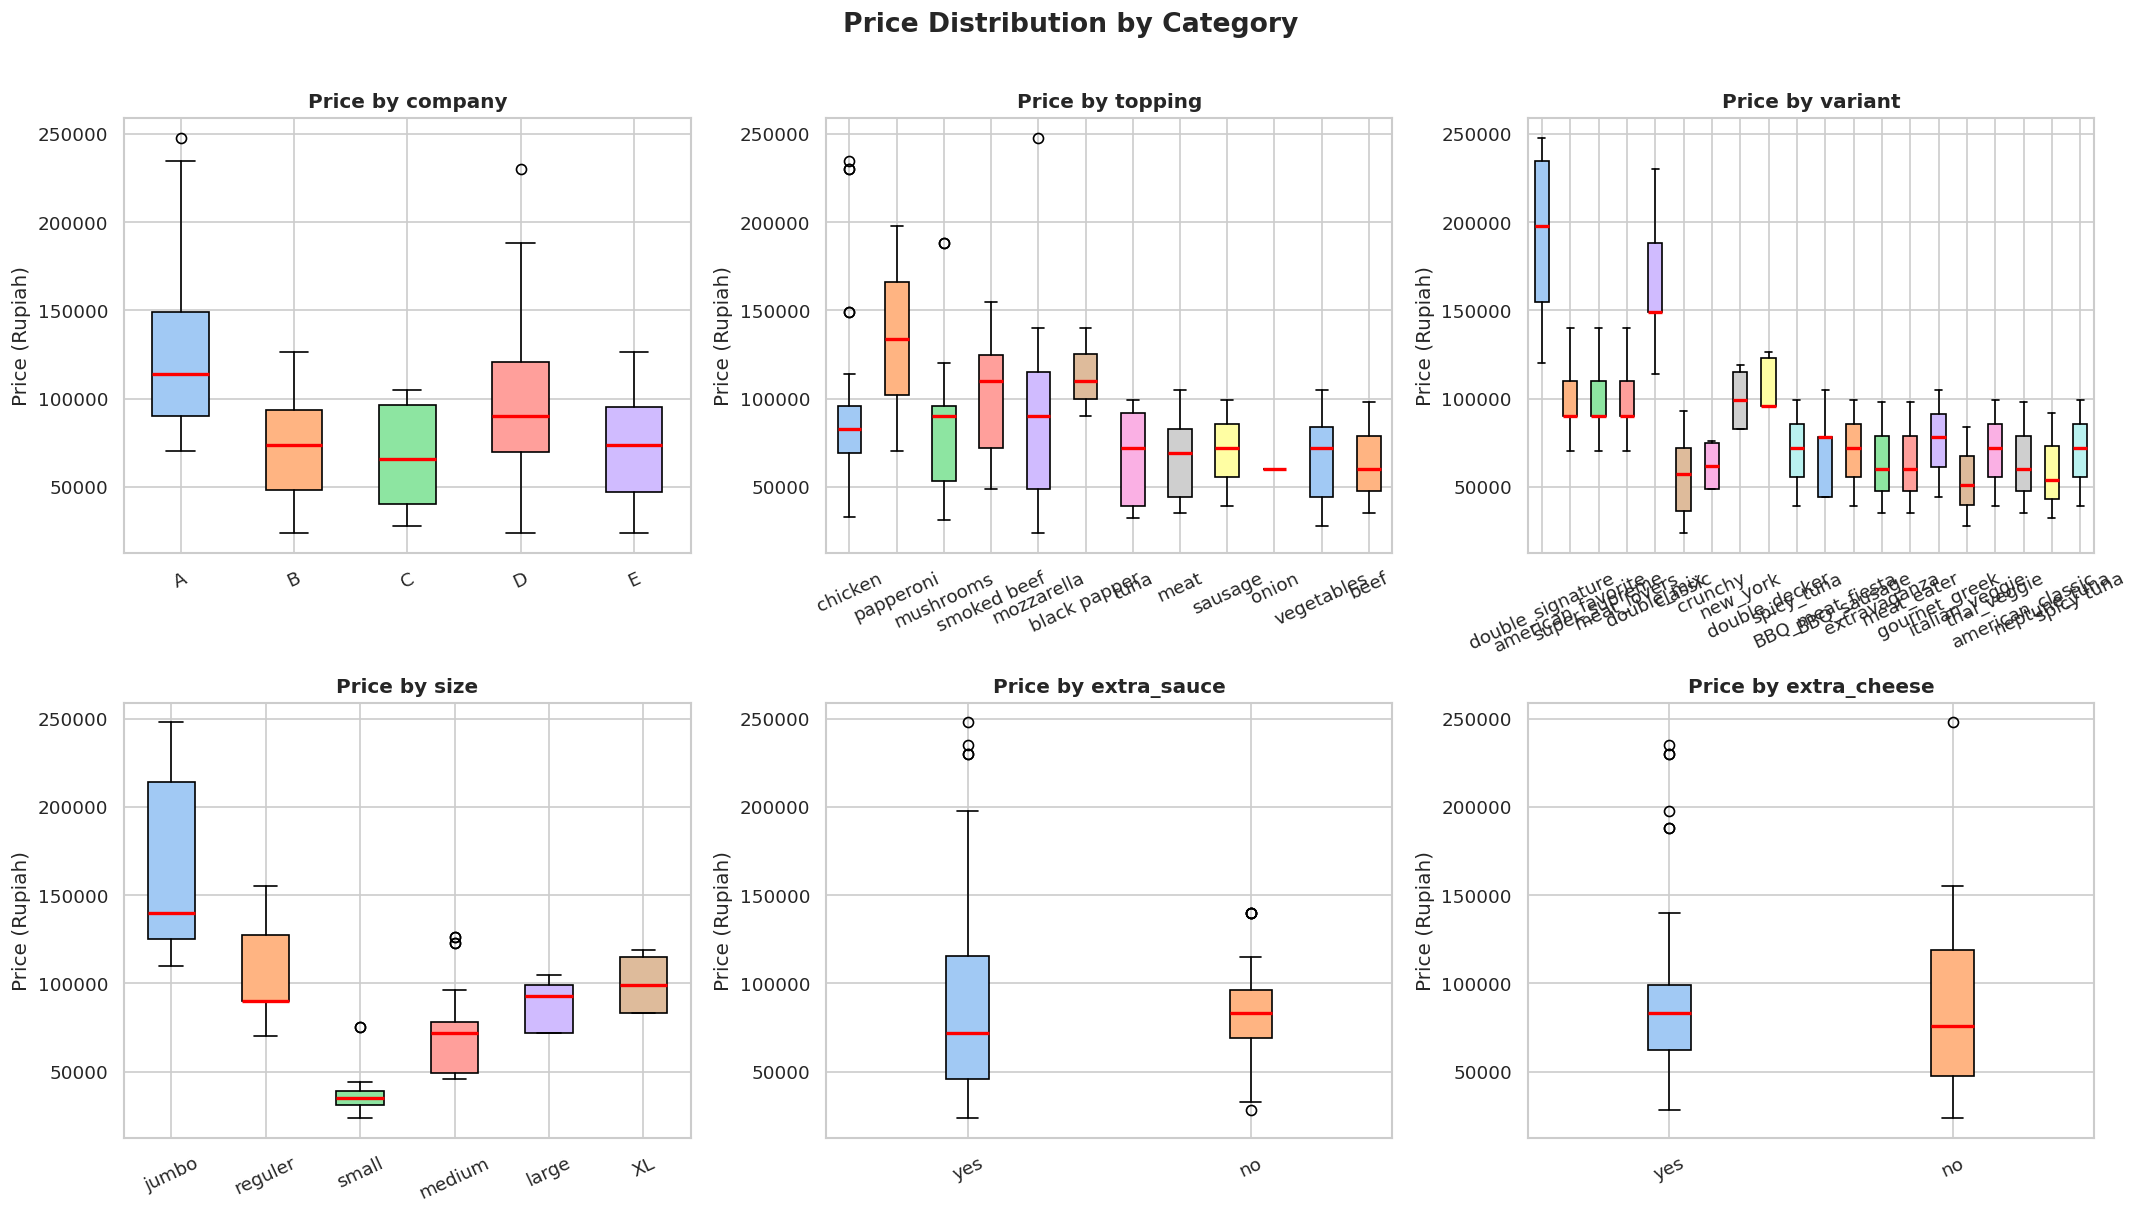

In [13]:
# ---- Price vs Categorical Features ----
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    groups = [df[df[col] == v]['price_rupiah'].values for v in df[col].unique()]
    bp = axes[i].boxplot(groups, labels=df[col].unique(), patch_artist=True,
                          medianprops=dict(color='red', linewidth=2))
    colors = sns.color_palette('pastel', len(groups))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    axes[i].set_title(f'Price by {col}', fontweight='bold')
    axes[i].set_ylabel('Price (Rupiah)')
    axes[i].tick_params(axis='x', rotation=25)

plt.suptitle('Price Distribution by Category', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 🏷️ Step 4 — Label Encoding

In [14]:
df_encoded = df.copy()

le = LabelEncoder()
label_encoders = {}

# Encode all string/object columns
string_cols = df_encoded.select_dtypes(include=['object', 'string']).columns.tolist()
print('Columns to encode:', string_cols)
print()

for col in string_cols:
    df_encoded[col] = df_encoded[col].astype(str)  # ensure str type
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le.classes_
    print(f'  {col} → {dict(enumerate(le.classes_))}')

print('\nEncoded dataset head:')
df_encoded.head()

Columns to encode: ['company', 'topping', 'variant', 'size', 'extra_sauce', 'extra_cheese']

  company → {0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'E'}
  topping → {0: 'beef', 1: 'black papper', 2: 'chicken', 3: 'meat', 4: 'mozzarella', 5: 'mushrooms', 6: 'onion', 7: 'papperoni', 8: 'sausage', 9: 'smoked beef', 10: 'tuna', 11: 'vegetables'}
  variant → {0: 'BBQ_meat_fiesta', 1: 'BBQ_sausage', 2: 'american_classic', 3: 'american_favorite', 4: 'classic', 5: 'crunchy', 6: 'double_decker', 7: 'double_mix', 8: 'double_signature', 9: 'extravaganza', 10: 'gournet_greek', 11: 'italian_veggie', 12: 'meat_eater', 13: 'meat_lovers', 14: 'neptune_tuna', 15: 'new_york', 16: 'spicy tuna', 17: 'spicy_tuna', 18: 'super_supreme', 19: 'thai_veggie'}
  size → {0: 'XL', 1: 'jumbo', 2: 'large', 3: 'medium', 4: 'reguler', 5: 'small'}
  extra_sauce → {0: 'no', 1: 'yes'}
  extra_cheese → {0: 'no', 1: 'yes'}

Encoded dataset head:


,company,price_rupiah,diameter,topping,variant,size,extra_sauce,extra_cheese
0,0,235000.0,22.0,2,8,1,1,1
1,0,198000.0,20.0,7,8,1,1,1
2,0,120000.0,16.0,5,8,4,1,1
3,0,155000.0,14.0,9,8,4,1,0
4,0,248000.0,18.0,4,8,1,1,0


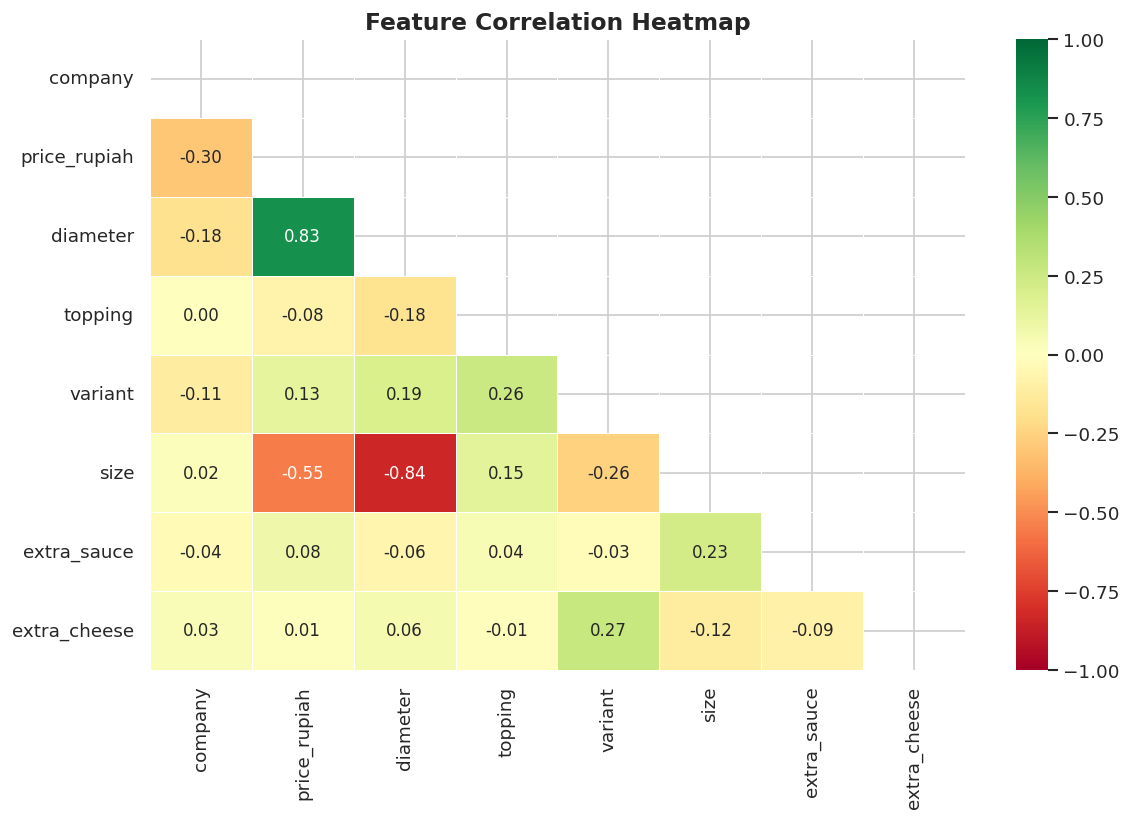


Correlation with price_rupiah:
price_rupiah    1.000000
diameter        0.826977
variant         0.130395
extra_sauce     0.083859
extra_cheese    0.011817
topping        -0.077875
company        -0.300033
size           -0.551606
Name: price_rupiah, dtype: float64


In [15]:
# ---- Correlation Heatmap ----
plt.figure(figsize=(10, 7))
corr = df_encoded.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, vmin=-1, vmax=1,
            annot_kws={'size': 10})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nCorrelation with price_rupiah:')
print(corr['price_rupiah'].sort_values(ascending=False))

## ✂️ Step 5 — Define Features & Target, then Train-Test Split

In [16]:
TARGET = 'price_rupiah'
FEATURES_ALL = [c for c in df_encoded.columns if c != TARGET]

X = df_encoded[FEATURES_ALL]
y = df_encoded[TARGET]

# For Simple Linear Regression, use only the strongest single predictor
best_feature = corr['price_rupiah'].drop('price_rupiah').abs().idxmax()
print(f'Best single predictor for Simple LR: {best_feature}')
X_simple = df_encoded[[best_feature]]

# Train-Test Split (80/20, random_state=42)
X_train_s, X_test_s, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42)

X_train_m, X_test_m, _, _ = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f'\nSimple LR  → Train: {X_train_s.shape}, Test: {X_test_s.shape}')
print(f'Multiple LR → Train: {X_train_m.shape}, Test: {X_test_m.shape}')

Best single predictor for Simple LR: diameter

Simple LR  → Train: (103, 1), Test: (26, 1)
Multiple LR → Train: (103, 7), Test: (26, 7)


## 📐 Step 6 — StandardScaler

In [17]:
scaler_s = StandardScaler()
scaler_m = StandardScaler()

# Fit ONLY on training data to avoid data leakage
X_train_s_sc = scaler_s.fit_transform(X_train_s)
X_test_s_sc  = scaler_s.transform(X_test_s)

X_train_m_sc = scaler_m.fit_transform(X_train_m)
X_test_m_sc  = scaler_m.transform(X_test_m)

print('StandardScaler applied.')
print(f'Simple LR  scaled train mean ≈ {X_train_s_sc.mean():.4f} (should be ~0)')
print(f'Multiple LR scaled train mean ≈ {X_train_m_sc.mean():.4f} (should be ~0)')

StandardScaler applied.
Simple LR  scaled train mean ≈ -0.0000 (should be ~0)
Multiple LR scaled train mean ≈ -0.0000 (should be ~0)


## 📈 Step 7 — Simple Linear Regression

In [18]:
slr = LinearRegression()
slr.fit(X_train_s_sc, y_train)

print(f'Simple LR Coefficient  : {slr.coef_[0]:.4f}')
print(f'Simple LR Intercept    : {slr.intercept_:.4f}')
print(f'\nEquation: price = {slr.intercept_:.2f} + {slr.coef_[0]:.2f} × {best_feature}_scaled')

Simple LR Coefficient  : 35009.1514
Simple LR Intercept    : 87495.1456

Equation: price = 87495.15 + 35009.15 × diameter_scaled


In [19]:
y_pred_slr = slr.predict(X_test_s_sc)

mae_s  = mean_absolute_error(y_test, y_pred_slr)
mse_s  = mean_squared_error(y_test, y_pred_slr)
rmse_s = np.sqrt(mse_s)
r2_s   = r2_score(y_test, y_pred_slr)

print('=== Simple Linear Regression — Test Metrics ===')
print(f'  MAE  : {mae_s:>12,.2f} Rp')
print(f'  MSE  : {mse_s:>12,.2f}')
print(f'  RMSE : {rmse_s:>12,.2f} Rp')
print(f'  R²   : {r2_s:>12.4f}')

=== Simple Linear Regression — Test Metrics ===
  MAE  :    21,442.17 Rp
  MSE  : 944,185,312.64
  RMSE :    30,727.60 Rp
  R²   :       0.6641


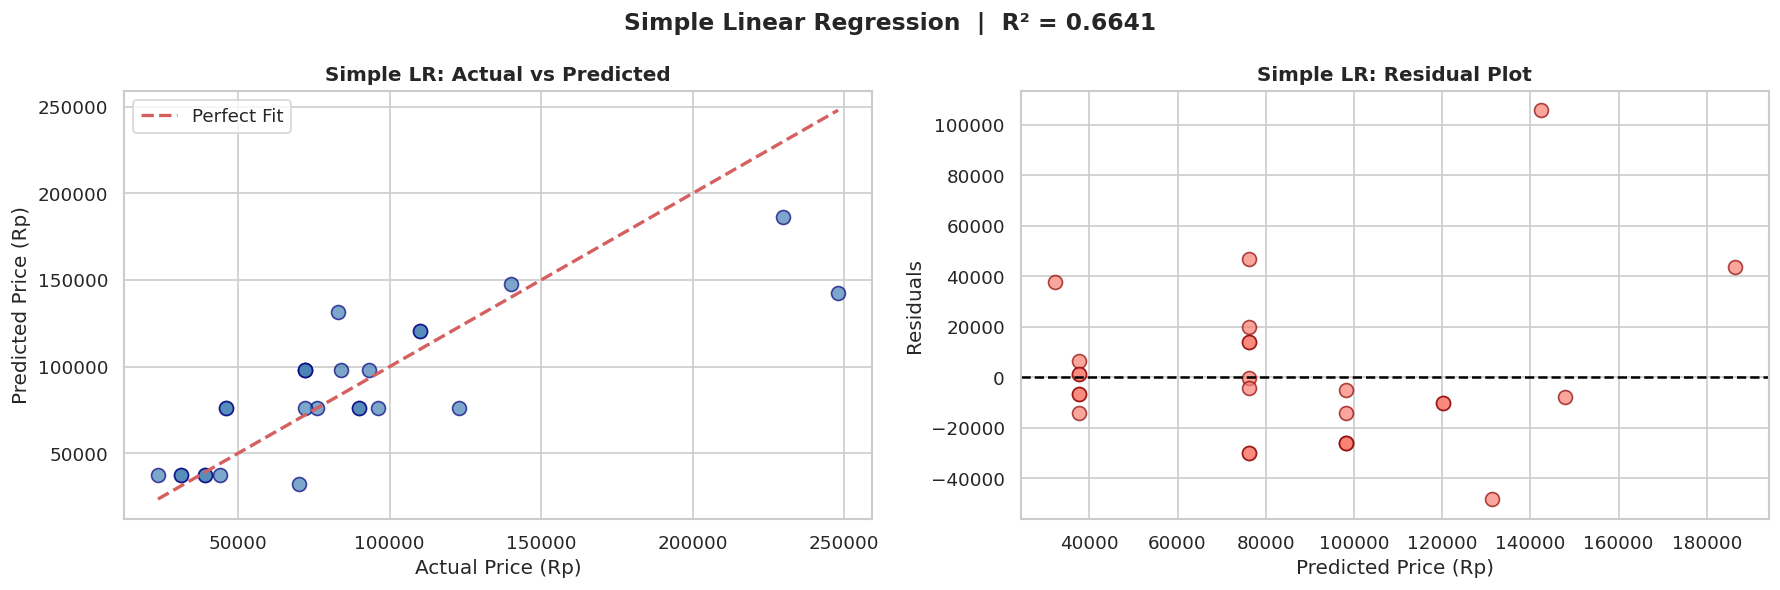

In [20]:
# ---- Simple LR: Actual vs Predicted ----
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Scatter: actual vs predicted
axes[0].scatter(y_test, y_pred_slr, alpha=0.7, c='steelblue', edgecolors='navy', s=70)
mn, mx = y_test.min(), y_test.max()
axes[0].plot([mn, mx], [mn, mx], 'r--', lw=2, label='Perfect Fit')
axes[0].set_title('Simple LR: Actual vs Predicted', fontweight='bold')
axes[0].set_xlabel('Actual Price (Rp)')
axes[0].set_ylabel('Predicted Price (Rp)')
axes[0].legend()

# Residual plot
residuals_s = y_test.values - y_pred_slr
axes[1].scatter(y_pred_slr, residuals_s, alpha=0.7, c='salmon', edgecolors='darkred', s=70)
axes[1].axhline(0, color='black', lw=1.5, linestyle='--')
axes[1].set_title('Simple LR: Residual Plot', fontweight='bold')
axes[1].set_xlabel('Predicted Price (Rp)')
axes[1].set_ylabel('Residuals')

plt.suptitle(f'Simple Linear Regression  |  R² = {r2_s:.4f}',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

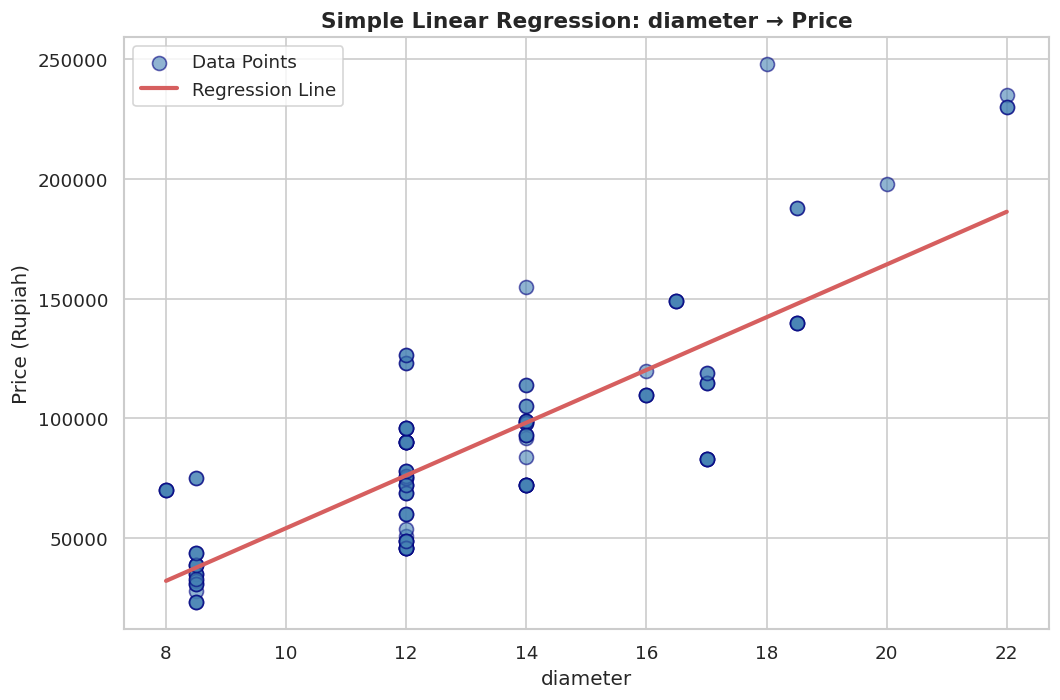

In [21]:
# ---- Regression Line on original (unscaled) axis ----
x_range = np.linspace(X_train_s.values.min(), X_train_s.values.max(), 300).reshape(-1, 1)
x_range_sc = scaler_s.transform(x_range)
y_line = slr.predict(x_range_sc)

plt.figure(figsize=(9, 6))
plt.scatter(X_simple, y, alpha=0.6, c='steelblue', edgecolors='navy',
            s=70, label='Data Points')
plt.plot(x_range, y_line, 'r-', lw=2.5, label='Regression Line')
plt.title(f'Simple Linear Regression: {best_feature} → Price', fontweight='bold', fontsize=13)
plt.xlabel(f'{best_feature}')
plt.ylabel('Price (Rupiah)')
plt.legend()
plt.tight_layout()
plt.show()

## 🔢 Step 8 — Multiple Linear Regression

In [22]:
mlr = LinearRegression()
mlr.fit(X_train_m_sc, y_train)

coef_df = pd.DataFrame({
    'Feature': FEATURES_ALL,
    'Coefficient': mlr.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print(f'Intercept: {mlr.intercept_:.4f}')
print('\nFeature Coefficients:')
print(coef_df.to_string(index=False))

Intercept: 87495.1456

Feature Coefficients:
     Feature  Coefficient
    diameter 48236.381486
        size 15730.402824
     topping  4594.017918
     company -4209.438947
 extra_sauce  3113.373772
     variant -2436.799082
extra_cheese  1193.045068


In [23]:
y_pred_mlr = mlr.predict(X_test_m_sc)

mae_m  = mean_absolute_error(y_test, y_pred_mlr)
mse_m  = mean_squared_error(y_test, y_pred_mlr)
rmse_m = np.sqrt(mse_m)
r2_m   = r2_score(y_test, y_pred_mlr)

print('=== Multiple Linear Regression — Test Metrics ===')
print(f'  MAE  : {mae_m:>12,.2f} Rp')
print(f'  MSE  : {mse_m:>12,.2f}')
print(f'  RMSE : {rmse_m:>12,.2f} Rp')
print(f'  R²   : {r2_m:>12.4f}')

=== Multiple Linear Regression — Test Metrics ===
  MAE  :    19,834.60 Rp
  MSE  : 833,345,395.06
  RMSE :    28,867.72 Rp
  R²   :       0.7035


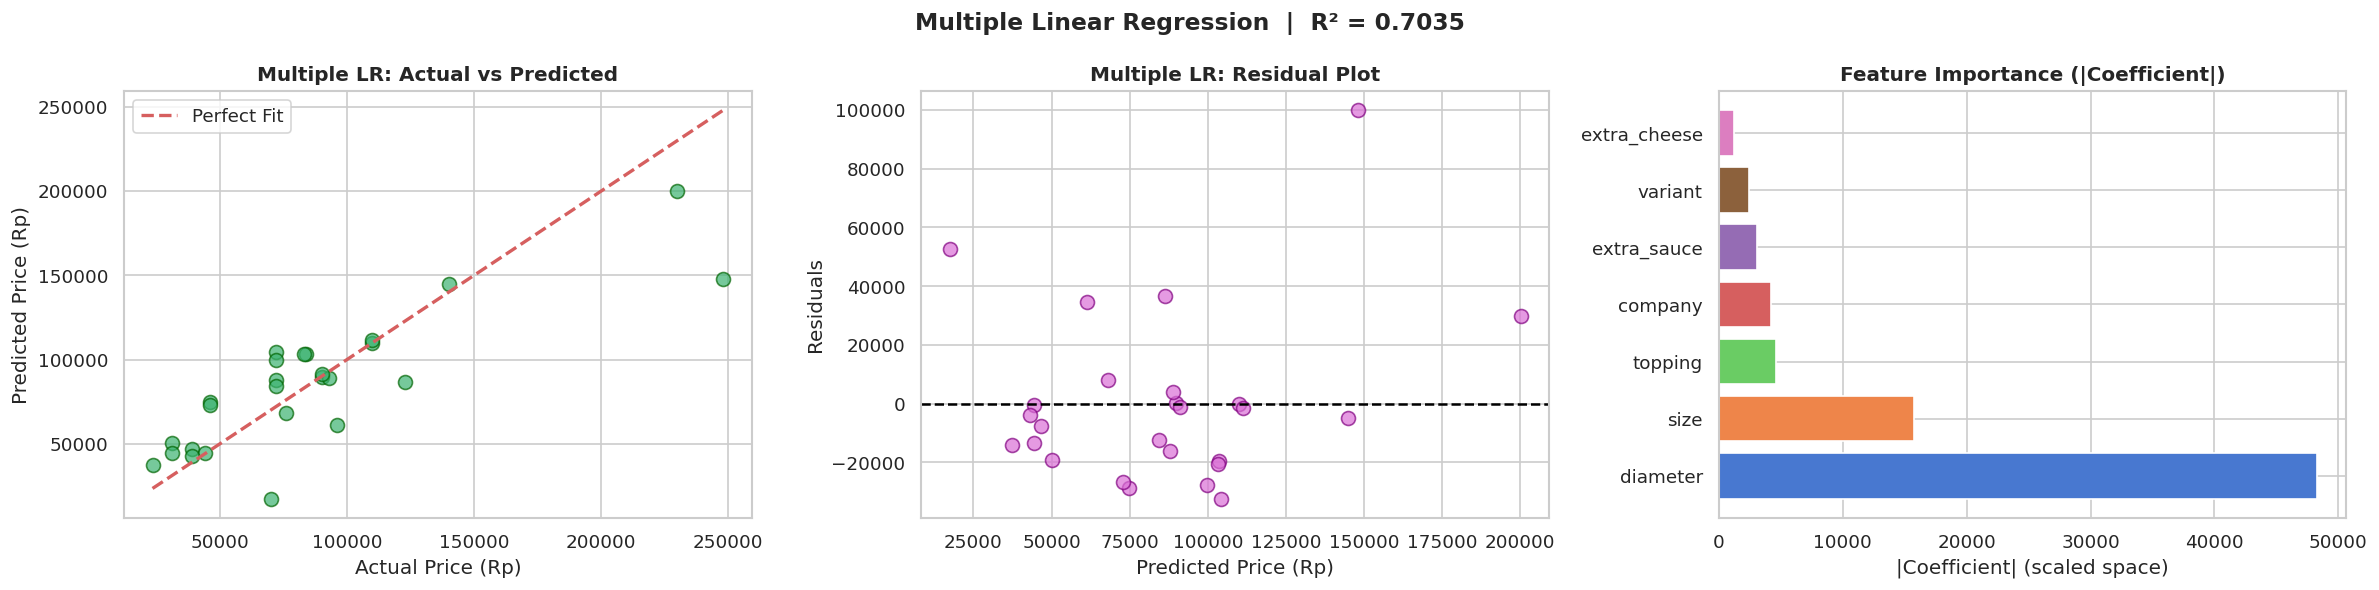

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Actual vs Predicted
axes[0].scatter(y_test, y_pred_mlr, alpha=0.7, c='mediumseagreen',
                edgecolors='darkgreen', s=70)
mn, mx = y_test.min(), y_test.max()
axes[0].plot([mn, mx], [mn, mx], 'r--', lw=2, label='Perfect Fit')
axes[0].set_title('Multiple LR: Actual vs Predicted', fontweight='bold')
axes[0].set_xlabel('Actual Price (Rp)')
axes[0].set_ylabel('Predicted Price (Rp)')
axes[0].legend()

# Residual plot
residuals_m = y_test.values - y_pred_mlr
axes[1].scatter(y_pred_mlr, residuals_m, alpha=0.7, c='orchid',
                edgecolors='purple', s=70)
axes[1].axhline(0, color='black', lw=1.5, linestyle='--')
axes[1].set_title('Multiple LR: Residual Plot', fontweight='bold')
axes[1].set_xlabel('Predicted Price (Rp)')
axes[1].set_ylabel('Residuals')

# Feature importance (absolute coefficients)
colors_bar = sns.color_palette('muted', len(coef_df))
axes[2].barh(coef_df['Feature'], coef_df['Coefficient'].abs(), color=colors_bar)
axes[2].set_title('Feature Importance (|Coefficient|)', fontweight='bold')
axes[2].set_xlabel('|Coefficient| (scaled space)')

plt.suptitle(f'Multiple Linear Regression  |  R² = {r2_m:.4f}',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## ⚖️ Step 9 — Model Comparison

In [25]:
results = pd.DataFrame({
    'Model'    : ['Simple Linear Regression', 'Multiple Linear Regression'],
    'MAE (Rp)' : [mae_s, mae_m],
    'RMSE (Rp)': [rmse_s, rmse_m],
    'R² Score' : [r2_s, r2_m]
})
print(results.to_string(index=False))

                     Model     MAE (Rp)    RMSE (Rp)  R² Score
  Simple Linear Regression 21442.165402 30727.598550   0.66412
Multiple Linear Regression 19834.602766 28867.722374   0.70355


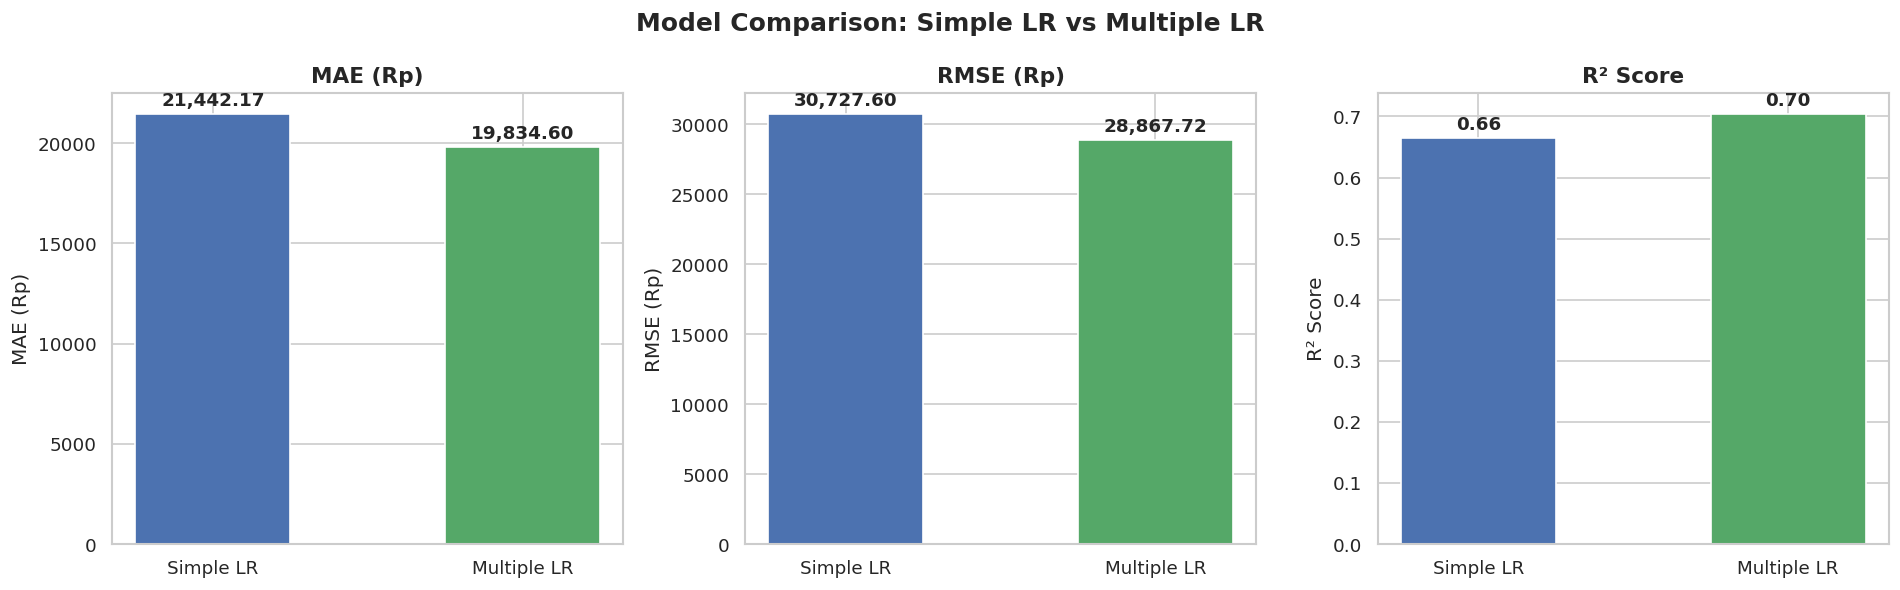

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
models   = ['Simple LR', 'Multiple LR']
palette  = ['#4C72B0', '#55A868']

for ax, metric, vals in zip(
        axes,
        ['MAE (Rp)', 'RMSE (Rp)', 'R² Score'],
        [[mae_s, mae_m], [rmse_s, rmse_m], [r2_s, r2_m]]):
    bars = ax.bar(models, vals, color=palette, edgecolor='white', width=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(vals) * 0.01,
                f'{val:,.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax.set_title(metric, fontweight='bold', fontsize=13)
    ax.set_ylabel(metric)

plt.suptitle('Model Comparison: Simple LR vs Multiple LR',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## ✅ Summary

| Step | Action |
|------|--------|
| 1 | Loaded `pizza_v1.csv` (129 rows × 8 cols) |
| 2 | Full EDA — distributions, boxplots, scatter plots, price by category |
| 3 | Cleaned `price_rupiah` (string → float) · Median/mode imputation |
| 4 | Label Encoding of all categorical columns |
| 5 | Correlation heatmap → identified best single predictor |
| 6 | Train-Test Split 80/20 (random_state=42) |
| 7 | StandardScaler fit on train, transform on test |
| 8 | Simple Linear Regression (1 feature) |
| 9 | Multiple Linear Regression (all features) |
| 10 | Evaluated with MAE, RMSE, R² — compared both models |

**Multiple LR** uses all available features and therefore typically achieves a higher R² — use it for production predictions.  
**Simple LR** serves as a baseline and helps visualise the single strongest relationship.